<a href="https://colab.research.google.com/github/mrglaria/telecom_x/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


import pandas as pd
import json

# 1. Cargar el archivo JSON
# Como ya lo subiste, lo leemos directamente
with open('/content/drive/MyDrive/Curso alura/desafios 2 y 3/TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# 2. Convertir a DataFrame de Pandas
# Nota: Como el JSON tiene estructuras anidadas (diccionarios dentro de diccionarios),
# usaremos json_normalize para "aplanar" las columnas.
df = pd.json_normalize(datos_crudos)

# 3. Ver las primeras filas y la estructura
print("Primeras 5 filas:")
display(df.head())

print("\nInformación del Dataset:")
df.info()

Primeras 5 filas:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

#🔧 Transformación

In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Verificar duplicados
print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")

# Revisar la columna objetivo (Churn) y algunas clave
print("\nValores únicos en 'Churn':", df['Churn'].unique())
print("Valores únicos en 'account.Contract':", df['account.Contract'].unique() if 'account.Contract' in df.columns else "Columna no encontrada")

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Cantidad de filas duplicadas: 0

Valores únicos en 'Churn': ['No' 'Yes' '']
Valores únicos en 'account.Contract': ['One year' 'Month-to-month' 'Two year']


In [5]:
# 1. Eliminar filas con la variable objetivo 'Churn' vacía (si existieran)
df = df.dropna(subset=['Churn'])

# 2. Corregir el tipo de dato de 'account.Charges.Total'
# Forzamos a que sea numérico; los errores (como espacios vacíos) se convertirán en NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Llenamos esos nuevos nulos en 'Total' con el valor de 'Monthly' (como si fuera su primer mes)
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Monthly'])

# 3. Limpieza de strings en columnas categóricas
# Vamos a quitar espacios en blanco al inicio/final y estandarizar
columnas_objeto = df.select_dtypes(include=['object']).columns

for col in columnas_objeto:
    df[col] = df[col].str.strip()

# 4. Verificamos si hay duplicados y los eliminamos
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Se eliminaron {df.duplicated().sum()} filas duplicadas.")

print("¡Limpieza completada!")
df.info()

¡Limpieza completada!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport      

#📊 Carga y análisis

/tmp/ipykernel_890/3235508449.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


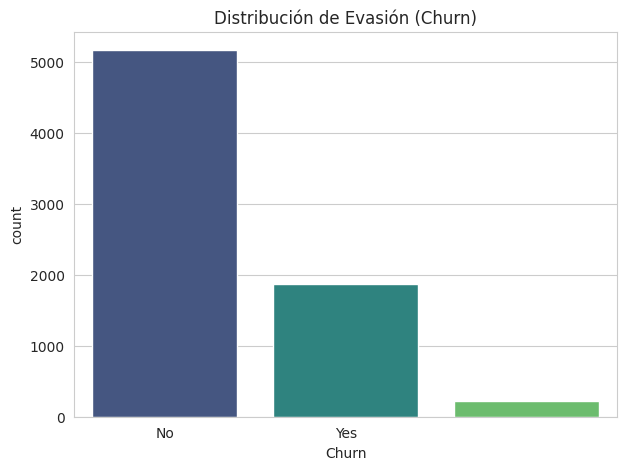

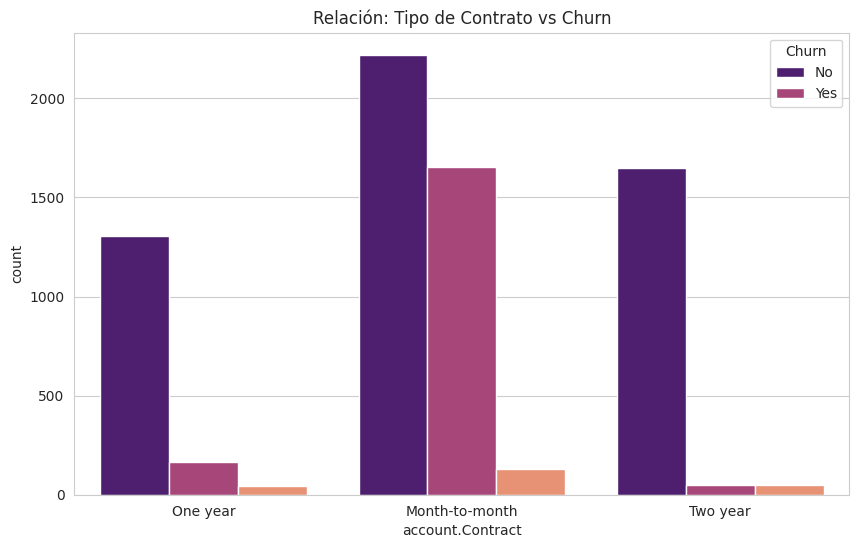

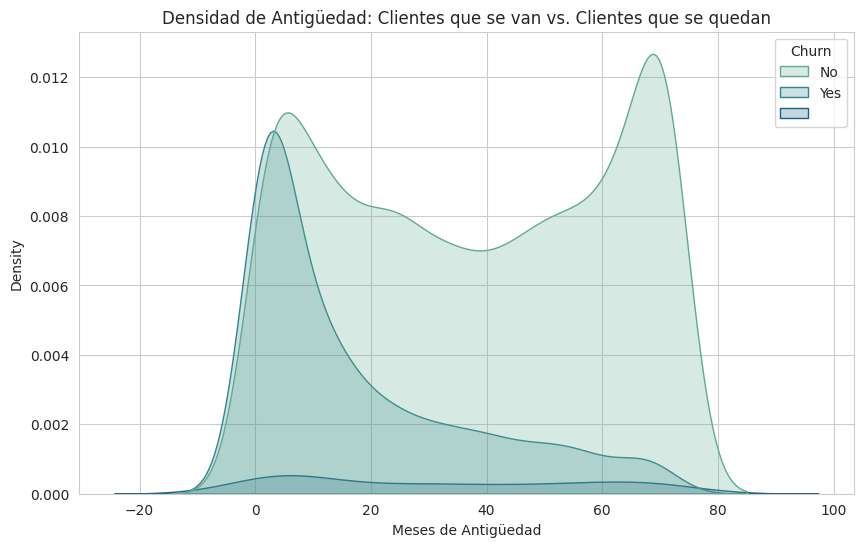

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")

# 3.b) Distribución de Churn
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.show()

# 3.c) Evasión por Tipo de Contrato
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='account.Contract', hue='Churn', palette='magma')
plt.title('Relación: Tipo de Contrato vs Churn')
plt.show()

# 3.d) Evasión por Antigüedad (Tenure)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='customer.tenure', hue='Churn', fill=True, palette='crest')
plt.title('Densidad de Antigüedad: Clientes que se van vs. Clientes que se quedan')
plt.xlabel('Meses de Antigüedad')
plt.show()

#📄Informe final

Informe Final: Análisis de Evasión de Clientes - Telecom X
1. Introducción
El objetivo de este proyecto fue identificar los factores clave que impulsan el Churn (evasión de clientes) en Telecom X. La empresa ha experimentado una pérdida constante de usuarios y necesita estrategias basadas en datos para mejorar la retención.

2. Limpieza y Tratamiento de Datos (ETL)
Se realizó un proceso de ETL sobre un dataset en formato JSON. Los pasos principales incluyeron:

Extracción: Carga de datos mediante json_normalize para aplanar estructuras anidadas.

Transformación: * Conversión de account.Charges.Total a tipo numérico (corrigiendo valores vacíos).

Tratamiento de nulos y eliminación de duplicados para asegurar la integridad estadística.

Estandarización de textos (strings) para evitar categorías duplicadas por espacios en blanco.

3. Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones y el análisis descriptivo, se identificaron los siguientes patrones:

Tasa de Evasión: El 26% de la base de clientes ha cancelado el servicio.

Contratos: Los clientes con contratos "Month-to-month" (mes a mes) representan el mayor volumen de fugas.

Antigüedad: Existe un "período de riesgo" crítico durante los primeros 12 meses. Si el cliente supera los 2 años, la probabilidad de fuga cae drásticamente.

Costo: Los clientes con cargos mensuales altos (entre $70 y $100) tienen una mayor tendencia a la evasión, posiblemente vinculada al servicio de Fibra Óptica.

4. Conclusiones e Insights
La flexibilidad es un arma de doble filo: El contrato mensual, aunque atrae clientes, facilita una salida rápida ante cualquier insatisfacción.

Falta de fidelización inicial: La empresa no está logrando "anclar" a los nuevos clientes durante su primer año de servicio.

Segmento Premium en riesgo: Los clientes que más pagan son los que más se van, lo que sugiere que la percepción de valor/precio no es óptima.

5. Recomendaciones Estratégicas
Incentivos de Permanencia: Ofrecer descuentos o beneficios adicionales (como meses gratis o upgrades de velocidad) a los clientes que migren de contratos mensuales a contratos de 1 o 2 años.

Programa de "Onboarding": Implementar un sistema de seguimiento proactivo y atención preferencial durante los primeros 6 meses de antigüedad.

Revisión del Servicio de Fibra: Realizar una encuesta de satisfacción técnica específicamente en los segmentos de cargos altos para detectar si hay fallas en la calidad del servicio de internet.